In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Loading both datasets
matches = pd.read_csv('../data/matches.csv')
deliveries = pd.read_csv('../data/deliveries.csv')

print("matches shape:", matches.shape)
print("deliveries shape:", deliveries.shape)

matches shape: (756, 18)
deliveries shape: (179078, 21)


In [3]:
matches.head()

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [4]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [5]:
matches.describe()

,id,dl_applied,win_by_runs,win_by_wickets
count,756.000000,756.000000,756.000000,756.000000
mean,1792.178571,0.025132,13.283069,3.350529
std,3464.478148,0.156630,23.471144,3.387963
min,1.000000,0.000000,0.000000,0.000000
25%,189.750000,0.000000,0.000000,0.000000
50%,378.500000,0.000000,0.000000,4.000000
75%,567.250000,0.000000,19.000000,6.000000
max,11415.000000,1.000000,146.000000,10.000000


In [6]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   Season           756 non-null    object
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

In [7]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179078 entries, 0 to 179077
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          179078 non-null  int64 
 1   inning            179078 non-null  int64 
 2   batting_team      179078 non-null  object
 3   bowling_team      179078 non-null  object
 4   over              179078 non-null  int64 
 5   ball              179078 non-null  int64 
 6   batsman           179078 non-null  object
 7   non_striker       179078 non-null  object
 8   bowler            179078 non-null  object
 9   is_super_over     179078 non-null  int64 
 10  wide_runs         179078 non-null  int64 
 11  bye_runs          179078 non-null  int64 
 12  legbye_runs       179078 non-null  int64 
 13  noball_runs       179078 non-null  int64 
 14  penalty_runs      179078 non-null  int64 
 15  batsman_runs      179078 non-null  int64 
 16  extra_runs        179078 non-null  int

In [8]:
top_scorers = deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False)
top_scorers.head(10)

batsman
V Kohli           5434
SK Raina          5415
RG Sharma         4914
DA Warner         4741
S Dhawan          4632
CH Gayle          4560
MS Dhoni          4477
RV Uthappa        4446
AB de Villiers    4428
G Gambhir         4223
Name: batsman_runs, dtype: int64

C:\Users\lenovo\AppData\Local\Temp\ipykernel_19396\1723979930.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scorers.head(10).values,


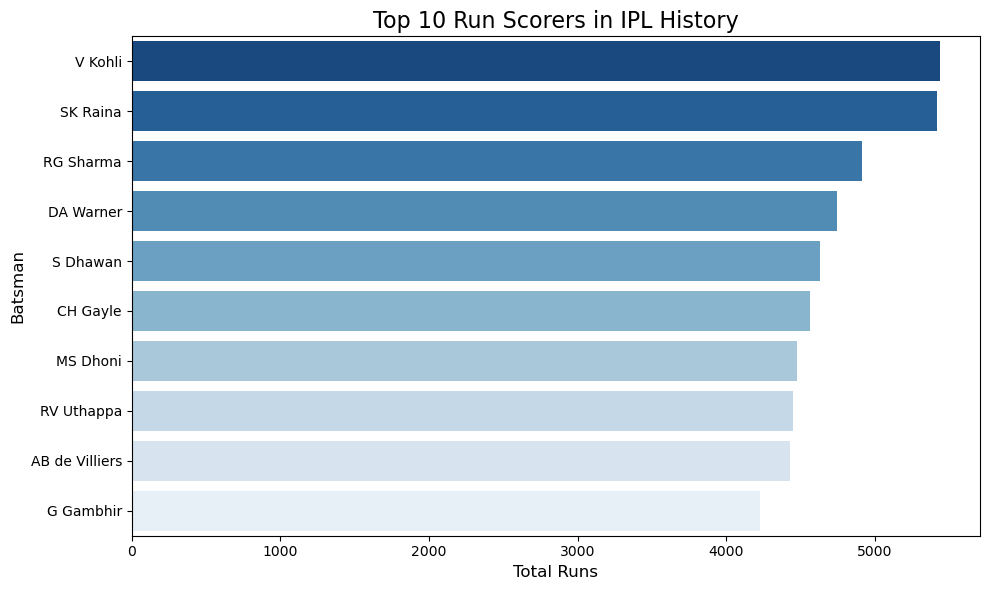

In [9]:
plt.figure(figsize=(10, 6))

sns.barplot(x=top_scorers.head(10).values, 
            y=top_scorers.head(10).index, 
            palette='Blues_r')

plt.title('Top 10 Run Scorers in IPL History', fontsize=16)
plt.xlabel('Total Runs', fontsize=12)
plt.ylabel('Batsman', fontsize=12)

plt.tight_layout()
plt.show()

In [10]:
deliveries['dismissal_kind'].value_counts()

dismissal_kind
caught                   5348
bowled                   1581
run out                   852
lbw                       540
stumped                   278
caught and bowled         211
retired hurt               12
hit wicket                 10
obstructing the field       2
Name: count, dtype: int64

In [11]:
bowler_wickets = ['caught', 'bowled', 'lbw', 'stumped', 'caught and bowled', 'hit wicket']
wickets_df = deliveries[deliveries['dismissal_kind'].isin(bowler_wickets)]
top_wicket_takers = wickets_df.groupby('bowler')['match_id'].count().sort_values(ascending=False)
top_wicket_takers.head(10)

bowler
SL Malinga         170
A Mishra           156
Harbhajan Singh    150
PP Chawla          149
DJ Bravo           147
B Kumar            133
R Ashwin           125
SP Narine          122
UT Yadav           119
RA Jadeja          108
Name: match_id, dtype: int64

C:\Users\lenovo\AppData\Local\Temp\ipykernel_19396\2949624499.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_wicket_takers.head(10).values,


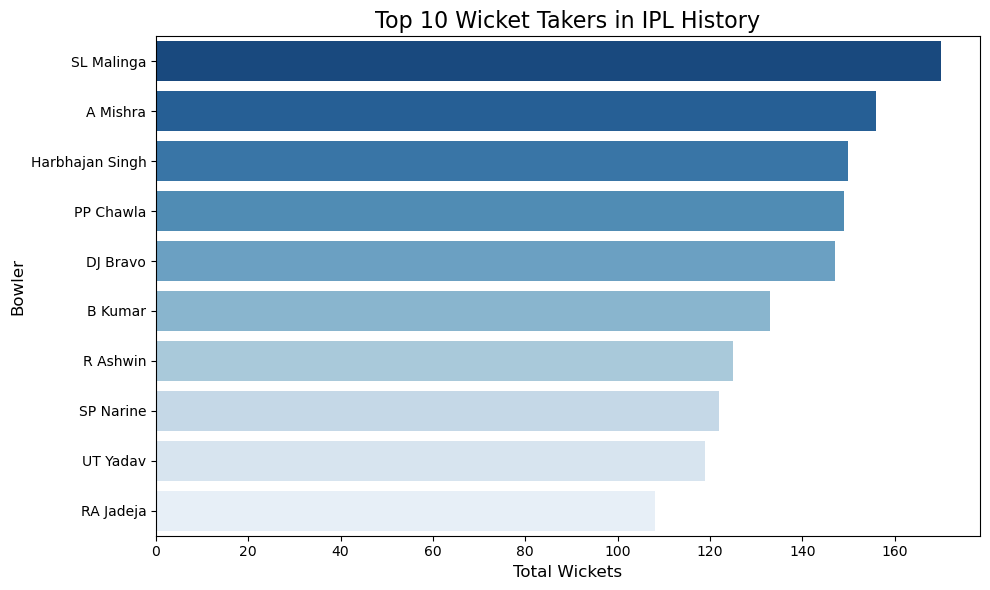

In [12]:
plt.figure(figsize=(10, 6))

sns.barplot(x=top_wicket_takers.head(10).values,
            y=top_wicket_takers.head(10).index,
            palette='Blues_r',
            legend=False)

plt.title('Top 10 Wicket Takers in IPL History', fontsize=16)
plt.xlabel('Total Wickets', fontsize=12)
plt.ylabel('Bowler', fontsize=12)

plt.tight_layout()
plt.show()

In [13]:
team_wins=matches['winner'].value_counts()
team_wins.head(25)

winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Rajasthan Royals                75
Delhi Daredevils                67
Sunrisers Hyderabad             58
Deccan Chargers                 29
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Delhi Capitals                  10
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64

In [14]:
all_teams_per_match = pd.concat([matches['team1'], matches['team2']])
matches_played = all_teams_per_match.value_counts()
matches_played.head(25)

Mumbai Indians                 187
Royal Challengers Bangalore    180
Kolkata Knight Riders          178
Kings XI Punjab                176
Chennai Super Kings            164
Delhi Daredevils               161
Rajasthan Royals               147
Sunrisers Hyderabad            108
Deccan Chargers                 75
Pune Warriors                   46
Gujarat Lions                   30
Rising Pune Supergiant          16
Delhi Capitals                  16
Kochi Tuskers Kerala            14
Rising Pune Supergiants         14
Name: count, dtype: int64

In [15]:
win_percentage = (team_wins / matches_played * 100).sort_values(ascending=False)
win_percentage.head(25)

Delhi Capitals                 62.500000
Rising Pune Supergiant         62.500000
Chennai Super Kings            60.975610
Mumbai Indians                 58.288770
Sunrisers Hyderabad            53.703704
Kolkata Knight Riders          51.685393
Rajasthan Royals               51.020408
Royal Challengers Bangalore    46.666667
Kings XI Punjab                46.590909
Gujarat Lions                  43.333333
Kochi Tuskers Kerala           42.857143
Delhi Daredevils               41.614907
Deccan Chargers                38.666667
Rising Pune Supergiants        35.714286
Pune Warriors                  26.086957
Name: count, dtype: float64

In [16]:
matches[matches['team1'].str.contains('Rising Pune', case=False)]['team1'].unique()

array(['Rising Pune Supergiant', 'Rising Pune Supergiants'], dtype=object)

In [17]:
matches[matches['team2'].str.contains('Rising Pune', case=False)]['team2'].unique()
matches[matches['winner'].str.contains('Rising Pune', case=False, na=False)]['winner'].unique()

array(['Rising Pune Supergiant', 'Rising Pune Supergiants'], dtype=object)

In [18]:
# Fix the inconsistent team name in all three relevant columns
name_fix = {'Rising Pune Supergiants': 'Rising Pune Supergiant'}

matches['team1'] = matches['team1'].replace(name_fix)
matches['team2'] = matches['team2'].replace(name_fix)
matches['winner'] = matches['winner'].replace(name_fix)

In [19]:
team_wins=matches['winner'].value_counts()
team_wins.head(25)

winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Rajasthan Royals                75
Delhi Daredevils                67
Sunrisers Hyderabad             58
Deccan Chargers                 29
Rising Pune Supergiant          15
Gujarat Lions                   13
Pune Warriors                   12
Delhi Capitals                  10
Kochi Tuskers Kerala             6
Name: count, dtype: int64

In [20]:
all_teams_per_match = pd.concat([matches['team1'], matches['team2']])
matches_played = all_teams_per_match.value_counts()
matches_played.head(25)

Mumbai Indians                 187
Royal Challengers Bangalore    180
Kolkata Knight Riders          178
Kings XI Punjab                176
Chennai Super Kings            164
Delhi Daredevils               161
Rajasthan Royals               147
Sunrisers Hyderabad            108
Deccan Chargers                 75
Pune Warriors                   46
Gujarat Lions                   30
Rising Pune Supergiant          30
Delhi Capitals                  16
Kochi Tuskers Kerala            14
Name: count, dtype: int64

In [21]:
win_percentage = (team_wins / matches_played * 100).sort_values(ascending=False)
win_percentage.head(25)

Delhi Capitals                 62.500000
Chennai Super Kings            60.975610
Mumbai Indians                 58.288770
Sunrisers Hyderabad            53.703704
Kolkata Knight Riders          51.685393
Rajasthan Royals               51.020408
Rising Pune Supergiant         50.000000
Royal Challengers Bangalore    46.666667
Kings XI Punjab                46.590909
Gujarat Lions                  43.333333
Kochi Tuskers Kerala           42.857143
Delhi Daredevils               41.614907
Deccan Chargers                38.666667
Pune Warriors                  26.086957
Name: count, dtype: float64

C:\Users\lenovo\AppData\Local\Temp\ipykernel_19396\2442789535.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=win_percentage.index,


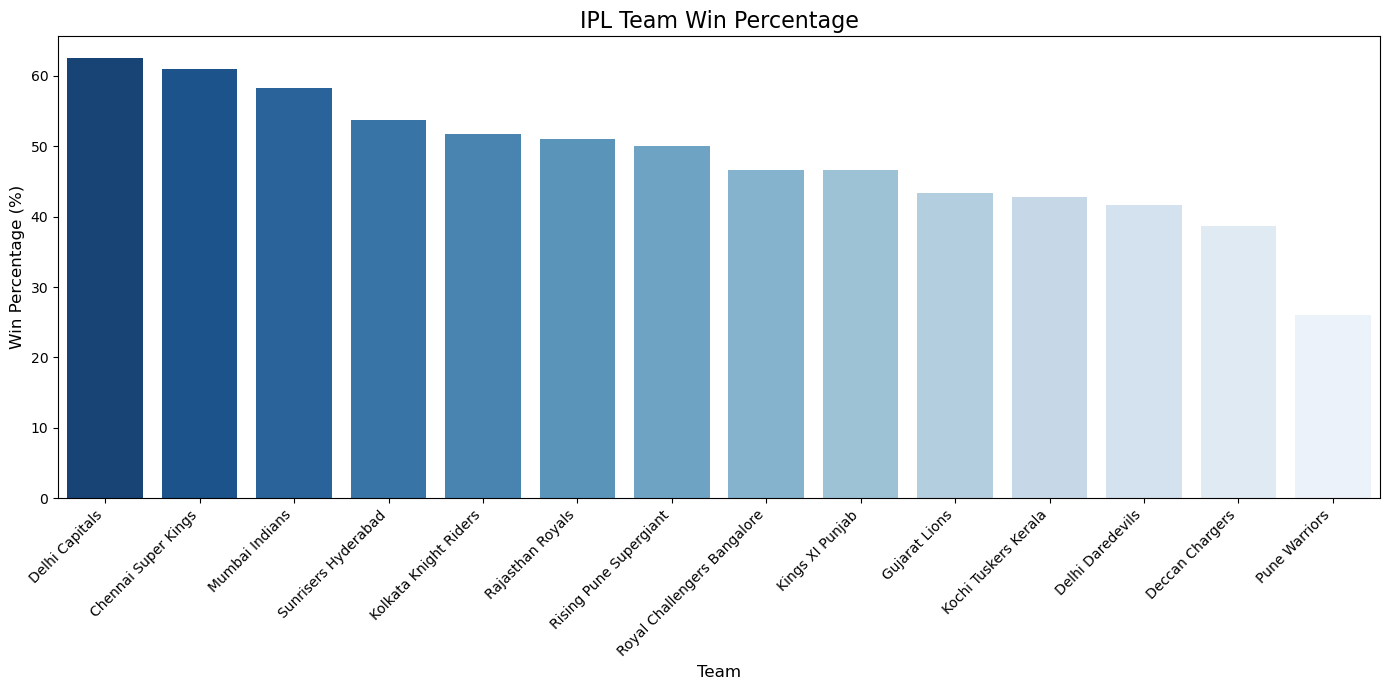

In [22]:
plt.figure(figsize=(14, 7))

sns.barplot(x=win_percentage.index,
            y=win_percentage.values,
            palette='Blues_r',
            legend=False)

plt.title('IPL Team Win Percentage', fontsize=16)
plt.xlabel('Team', fontsize=12)
plt.ylabel('Win Percentage (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [23]:
(matches['toss_winner'] == matches['winner']).sum()  

np.int64(390)

In [24]:
toss_win_match_win=(matches['toss_winner']==matches['winner']).sum()/len(matches) * 100
print(f"Toss winner also won the match: {toss_win_match_win:.2f}%")

Toss winner also won the match: 51.59%


In [25]:
# Step 1 - filter to matches where toss winner won
toss_winner_won = matches[matches['toss_winner'] == matches['winner']]

# Step 2 - what decision did they make?
toss_winner_won['toss_decision'].value_counts()

toss_decision
field    256
bat      134
Name: count, dtype: int64

In [26]:
matches['toss_decision'].value_counts()

toss_decision
field    463
bat      293
Name: count, dtype: int64

In [27]:
toss_decision_counts = matches['toss_decision'].value_counts()
toss_winner_decision = toss_winner_won['toss_decision'].value_counts()

decision_win_pct = (toss_winner_decision / toss_decision_counts * 100).round(2)
print(decision_win_pct)

toss_decision
field    55.29
bat      45.73
Name: count, dtype: float64


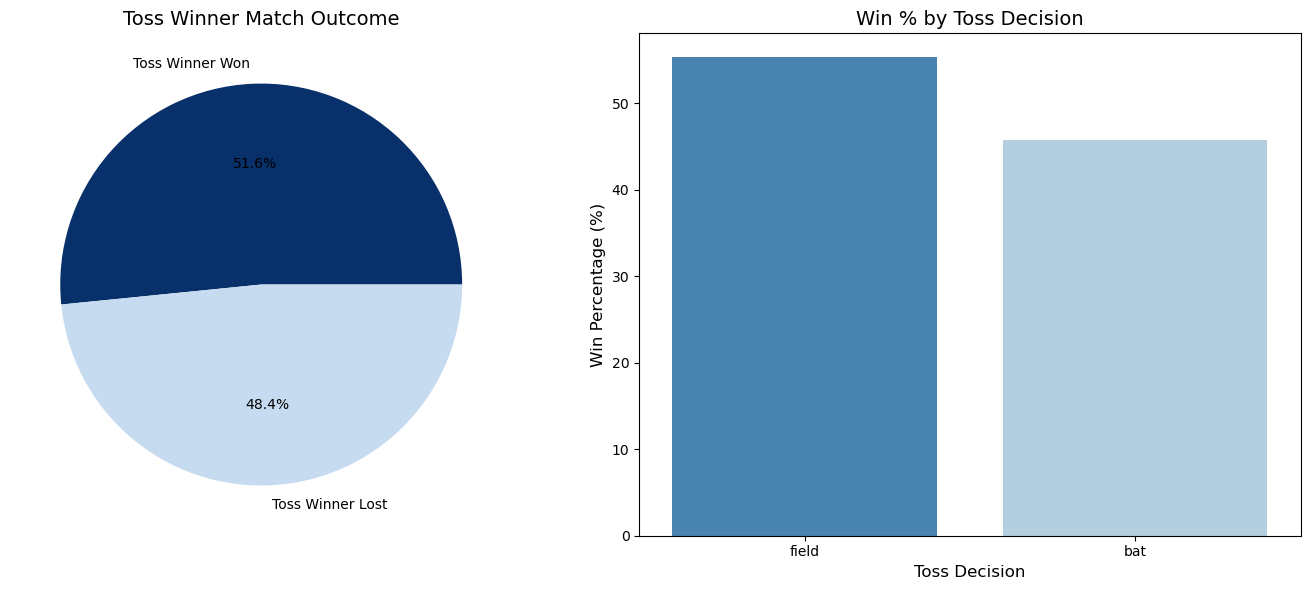

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 - Pie chart on the left
axes[0].pie([toss_win_match_win, 100 - toss_win_match_win],
            labels=['Toss Winner Won', 'Toss Winner Lost'],
            autopct='%1.1f%%',
            colors=['#08306b', '#c6dbef'])
axes[0].set_title('Toss Winner Match Outcome', fontsize=14)

# Chart 2 - Bar chart on the right
sns.barplot(x=decision_win_pct.index,
            y=decision_win_pct.values,
            palette='Blues_r',
            hue=decision_win_pct.index,
            legend=False,
            ax=axes[1])
axes[1].set_title('Win % by Toss Decision', fontsize=14)
axes[1].set_xlabel('Toss Decision', fontsize=12)
axes[1].set_ylabel('Win Percentage (%)', fontsize=12)

plt.tight_layout()
plt.show()

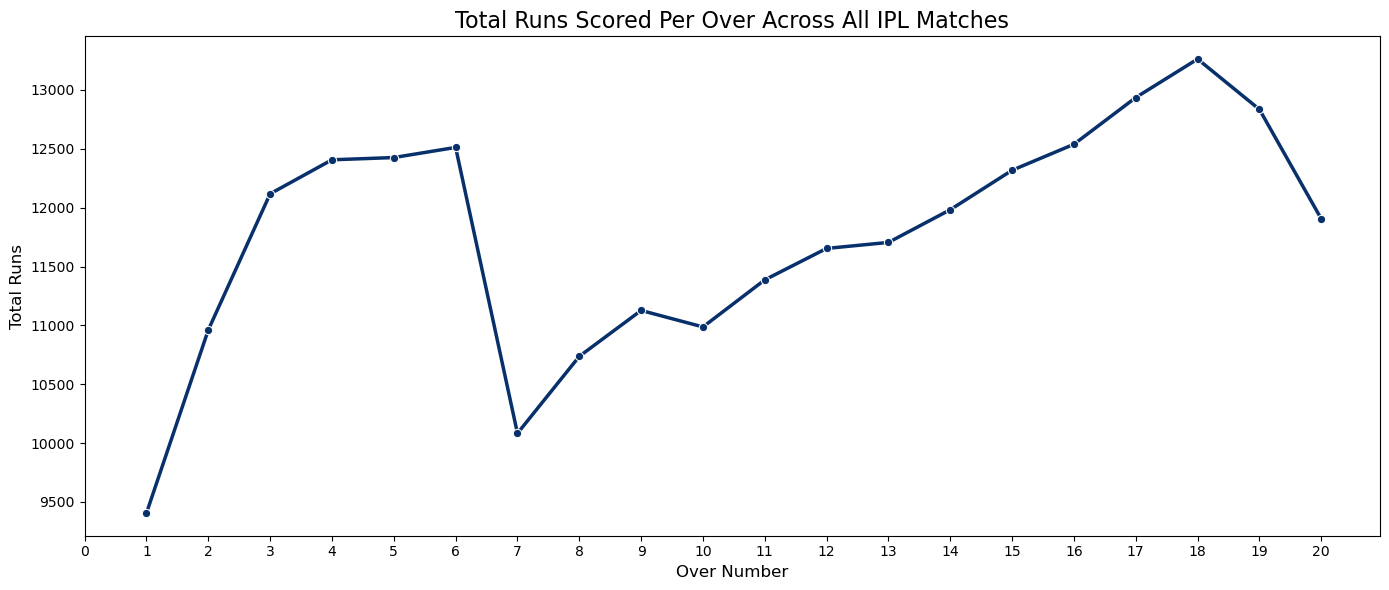

In [30]:
runs_per_over = deliveries.groupby('over')['total_runs'].sum()

plt.figure(figsize=(14, 6))

sns.lineplot(x=runs_per_over.index,
             y=runs_per_over.values,
             color='#08306b',
             linewidth=2.5,
             marker='o',
             markersize=6)

plt.title('Total Runs Scored Per Over Across All IPL Matches', fontsize=16)
plt.xlabel('Over Number', fontsize=12)
plt.ylabel('Total Runs', fontsize=12)
plt.xticks(range(0, 21))

plt.tight_layout()
plt.show()